In [1]:
# Задача 1 - Когортный анализ

In [2]:
import pandas as pd
import numpy as np
from operator import attrgetter
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

In [3]:
# Откроем исходные датасеты
customers_dataset = pd.read_csv('olist_customers_dataset.csv')
items_dataset = pd.read_csv('olist_order_items_dataset.csv')
orders_dataset = pd.read_csv('olist_orders_dataset.csv')

In [4]:
customers_dataset

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [5]:
items_dataset

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [6]:
# Объединим нужные в работе датасеты и создадим копию для безопасной работы
order_and_customers = orders_dataset.merge(customers_dataset, on='customer_id', how = 'left')

In [7]:
order_and_customers_copy = order_and_customers.copy()

In [8]:
order_and_customers_copy['order_purchase_timestamp'] = pd.to_datetime(order_and_customers_copy['order_purchase_timestamp'])
order_and_customers_copy['order_delivered_customer_date'] = pd.to_datetime(order_and_customers_copy['order_delivered_customer_date'])
order_and_customers_copy['order_estimated_delivery_date'] = pd.to_datetime(order_and_customers_copy['order_estimated_delivery_date'])

In [9]:
all_data = order_and_customers_copy.merge(items_dataset, on='order_id', how = 'inner')

In [10]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 112650 entries, 0 to 112649
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   customer_id                    112650 non-null  object        
 2   order_status                   112650 non-null  object        
 3   order_purchase_timestamp       112650 non-null  datetime64[ns]
 4   order_approved_at              112635 non-null  object        
 5   order_delivered_carrier_date   111456 non-null  object        
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  112650 non-null  datetime64[ns]
 8   customer_unique_id             112650 non-null  object        
 9   customer_zip_code_prefix       112650 non-null  int64         
 10  customer_city                  112650 non-null  object        
 11  

In [11]:
# Проанализируем статусы заказов и исключим из датасета отменённые, недоступные и не подтверждённые заказы
order_and_customers_copy.order_status.value_counts()

delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_status, dtype: int64

In [12]:
order_and_customers_copy = order_and_customers_copy.query('~(order_status == "canceled" or order_status == "unavailable")')
order_and_customers_copy = order_and_customers_copy.query('order_approved_at.notna()')

In [13]:
# Подготовим данные для когортного анализа
order_and_customers_copy['order_period_day'] = order_and_customers_copy['order_purchase_timestamp'].dt.to_period('D')

In [14]:
order_and_customers_copy['cohort'] = order_and_customers_copy.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
order_and_customers_copy['cohort_day'] = order_and_customers_copy.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')

In [15]:
order_and_customers_copy['period_number_month'] = np.floor((order_and_customers_copy.order_period_day - order_and_customers_copy.cohort_day).apply(attrgetter('n')) / 30)

In [16]:
df_cohort = order_and_customers_copy.groupby(['cohort', 'period_number_month']).agg(n_customers=('customer_unique_id', 'nunique')).reset_index()

In [17]:
cohort_pivot = df_cohort.pivot_table(index='cohort', columns='period_number_month', values='n_customers')

In [18]:
cohort_size = cohort_pivot.iloc[:, 0]

In [19]:
# Проведём когортный анализ
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

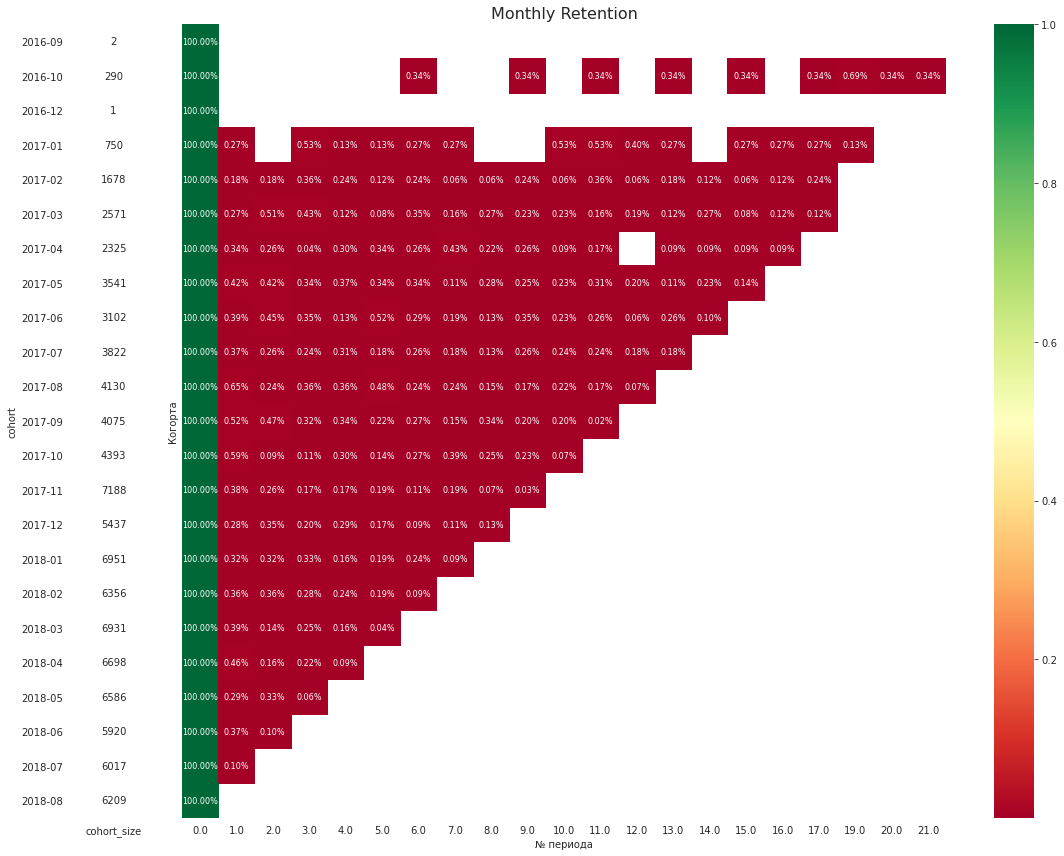

In [20]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.2%',
                cmap='RdYlGn',
                ax=ax[1],
                annot_kws={"size": 8}) 
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])
                

    fig.tight_layout()
    plt.show()

In [21]:
# Вычислим медиану первого месяца и максимум третьего месяца
median_retention_1 = retention_matrix[1.0].median()
print(f"Медианный retention 1-го месяца: {median_retention_1:.2%}")

Медианный retention 1-го месяца: 0.37%


In [22]:
max_retention_3 = retention_matrix[3.0].max()
print(f"Максимальный retention 3-го месяца: {max_retention_3:.2%}")

Максимальный retention 3-го месяца: 0.53%


In [23]:
# Задача 2 - PMF

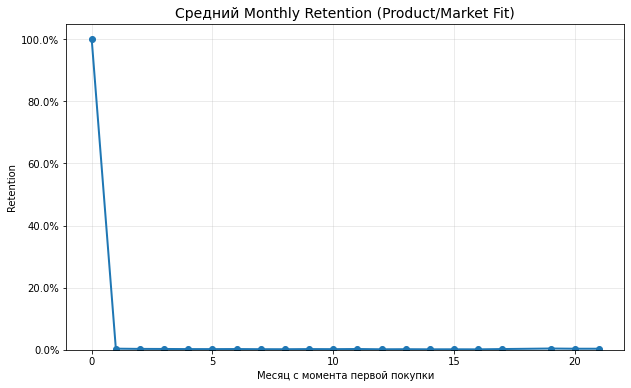

In [24]:
# Средний retention по периодам
avg_retention = retention_matrix.mean()

plt.figure(figsize=(10, 6))
plt.plot(avg_retention.index, avg_retention.values, marker='o', linewidth=2)
plt.title('Средний Monthly Retention (Product/Market Fit)', fontsize=14)
plt.xlabel('Месяц с момента первой покупки')
plt.ylabel('Retention')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.show()

In [25]:
'''
Когортный анализ показывает низкую долю повторных покупок в исследуемом
периоде. Это может говорить о слабом удержании клиентов, однако на основании
одного retention нельзя однозначно сделать вывод об отсутствии Product Market Fit.

Низкая повторная покупка может быть связана со спецификой маркетплейса:
часть товаров приобретается редко и только при возникновении потребности.

Также возможные причины низкого retention:

1. Клиенты сталкиваются с отменой первого заказа и теряют доверие к платформе.

2. Пользователи могут быть недовольны сроками доставки, стоимостью доставки
или недостаточной прозрачностью статусов заказа.

3. После первой покупки отсутствуют механики возврата клиентов:
программа лояльности, персональные предложения и триггерные коммуникации.

После устранения проблемы с отменами необходимо повторно оценить retention
на горизонте 30, 60 и 90 дней. Если он не вырастет, потребуется проверить
ассортимент, цены, качество товаров и клиентский опыт после первой покупки.
'''

In [26]:
f"{(order_and_customers_copy.query('order_delivered_customer_date > order_estimated_delivery_date').order_id.count()/order_and_customers_copy.order_id.count()):.2%}"

'7.97%'

In [27]:
# Задача 3 - 5 метрик

In [28]:
# 1 - GMV - Gross Merchandise Volume

In [29]:
all_data['order_period_month'] = all_data['order_purchase_timestamp'].dt.to_period('M')

In [30]:
GMV = all_data.groupby('order_period_month').agg({'price' : 'sum'})

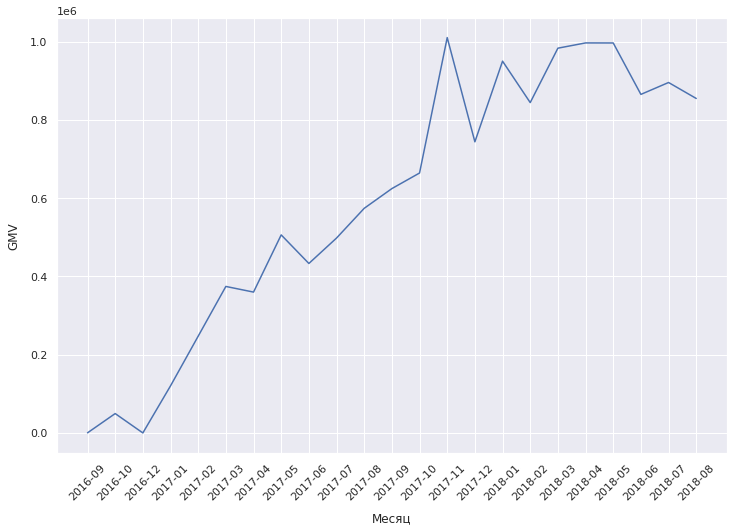

In [31]:
sns.set()
plt.figure(figsize=(12,8))
plt.plot(GMV.iloc[:-1].index.astype(str), GMV.iloc[:-1].values)

plt.title('', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Месяц', fontsize=12, labelpad=10)
plt.ylabel('GMV', fontsize=12, labelpad=10)
plt.xticks(rotation=45); 

In [32]:
# 2 - MAU - Monthly Active Users

In [33]:
MAU = all_data.groupby('order_period_month').agg({'customer_unique_id' : 'nunique'})

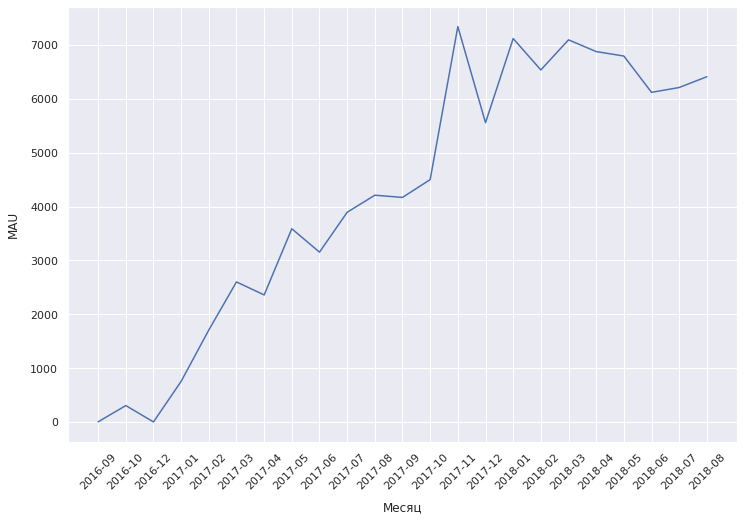

In [34]:
plt.figure(figsize=(12,8))
plt.plot(MAU.iloc[:-1].index.astype(str),MAU.iloc[:-1].values)

plt.title('', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Месяц', fontsize=12, labelpad=10)
plt.ylabel('MAU', fontsize=12, labelpad=10)
plt.xticks(rotation=45); 


In [35]:
# 3 - CTR - Click-Through Rate

In [36]:
# 4 - Retention Rate

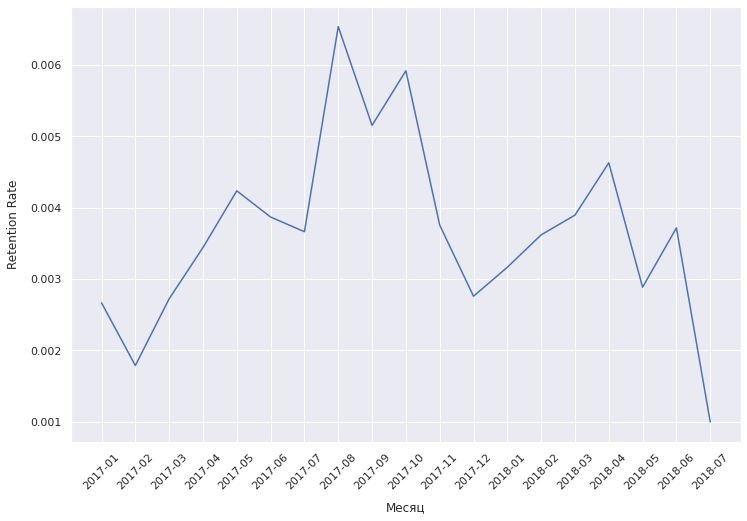

In [37]:
plt.figure(figsize=(12,8))

plt.tight_layout() 
plt.plot(retention_matrix[1.0].iloc[:-1].index.astype(str),
        retention_matrix[1.0].iloc[:-1].values)

plt.title('', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Месяц', fontsize=12, labelpad=10)
plt.ylabel('Retention Rate', fontsize=12, labelpad=10)
plt.xticks(rotation=45); 

In [38]:
# 5 - LTV - Lifetime Value / ARPPU - Average Revenue Per Paying User

In [39]:
all_data_copy = all_data.query('~(order_status == "canceled" or order_status == "unavailable")')
all_data_copy = all_data_copy.query('order_approved_at.notna()')

In [40]:
all_data_copy['order_period_day'] = all_data_copy['order_purchase_timestamp'].dt.to_period('D')
all_data_copy['cohort'] = all_data_copy.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
all_data_copy['cohort_day'] = all_data_copy.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')

In [41]:
all_data_copy['period_number_month'] = np.floor((all_data_copy.order_period_day - all_data_copy.cohort_day).apply(attrgetter('n')) / 30)

In [42]:
df_cohort_2 = all_data_copy.groupby(['cohort', 'period_number_month']).agg(n_customers=('price', 'sum')).reset_index()

In [44]:
cohort_pivot_2 = df_cohort_2.pivot_table(index='cohort', columns = 'period_number_month', values='n_customers')

In [45]:
cumsum = cohort_pivot_2.cumsum(axis=1)

In [47]:
retention_matrix_2 = cumsum.divide(cohort_size, axis=0)

In [48]:
retention_matrix_2

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,103.930000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,153.473448,NaN,NaN,NaN,NaN,NaN,153.818241,NaN,NaN,154.987207,...,155.156172,NaN,155.553414,NaN,156.583069,NaN,156.921000,157.918517,158.375069,158.46469
2016-12,21.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,160.168533,160.279053,NaN,160.645320,160.725307,160.853307,161.222573,161.363507,NaN,NaN,...,162.421173,162.866360,162.996893,NaN,163.256760,163.381960,163.761680,163.812347,NaN,NaN
2017-02,145.223355,145.332521,145.538004,145.936156,146.186073,146.466049,146.584631,146.691901,146.876585,147.219648,...,147.547884,147.612247,147.778993,147.864690,147.934416,148.102294,148.346311,NaN,NaN,NaN
2017-03,143.379701,143.719487,144.786783,145.161661,145.355706,145.728324,146.091396,146.393108,146.775368,146.877495,...,147.402633,147.621342,147.718110,147.997690,148.152377,148.255406,148.362637,NaN,NaN,NaN
2017-04,152.189983,152.615118,153.031966,153.057729,153.537325,154.174013,154.819591,155.505927,155.686056,155.931811,...,156.323028,NaN,156.462770,156.601114,156.943006,157.018271,NaN,NaN,NaN,NaN
2017-05,141.107235,141.420184,142.191929,142.590240,143.004807,143.648447,144.048947,144.133330,144.522496,144.904019,...,145.537625,145.693084,145.729735,145.978458,146.068461,NaN,NaN,NaN,NaN,NaN
2017-06,137.122482,137.576618,138.281937,138.549761,138.819420,139.454845,139.725368,139.923166,140.003072,140.552808,...,141.422299,141.470567,141.988968,142.436067,NaN,NaN,NaN,NaN,NaN,NaN


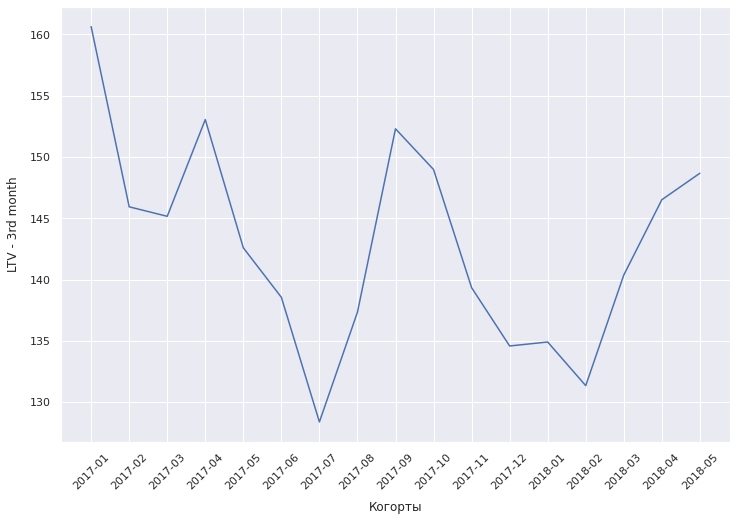

In [49]:
plt.figure(figsize=(12,8))
plt.tight_layout()

plt.plot(retention_matrix_2[3.0].iloc[:-1].index.astype(str),
        retention_matrix_2[3.0].iloc[:-1].values)

plt.title('', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Когорты', fontsize=12, labelpad=10)
plt.ylabel('LTV - 3rd month', fontsize=12, labelpad=10)
plt.xticks(rotation=45); 

In [50]:
# Задача 4. Выбор гипотезы 

In [51]:
Hypoteze_1 = all_data.query('order_period_month > "2017-05" and order_status == "canceled"').order_id.count()
Hypoteze_1

431

In [52]:
Hypoteze_2 = all_data.query('order_period_month > "2017-05" and order_delivered_customer_date > order_estimated_delivery_date').order_id.count() * median_retention_1
Hypoteze_2

29.721611721611723

In [53]:
customers = all_data.query('order_period_month > "2017-05"').groupby('customer_unique_id')['order_id'].count()
Hypoteze_3 = customers[customers == 1].shape[0] *median_retention_1
Hypoteze_3

271.6336996336996

In [54]:
ICE_1 = 4*8*6
ICE_1

# Вывод: выбираем гипотезу номер 1

192

In [55]:
ICE_2 = 1*10*4
ICE_2

40

In [56]:
ICE_3 = 3*5*9
ICE_3

135

In [57]:
# Задача 5. Выбор метрик

In [58]:
# Метрики на которые будет оказано влияние:
"""
Целевые

Количество доставленных заказов
Доля успешно доставленных заказов от общего числа оформленных заказов
Доля отменённых заказов
GMV доставленных заказов на один оформленный заказ

Прокси

Доля заказов, прошедших подтверждение
Среднее время от оформления заказа до его подтверждения
Доля заказов, зависших в статусах created / processing дольше X часов

Guardrail

Доля заказов, доставленных с опозданием
Доля ошибочных списаний / дублирующих заказов
CSAT / NPS после получения заказа
Доля негативных отзывов, связанных с процессом заказа
Стоимость логистики / фулфилмента на доставленный заказ
Средний чек (AOV)
"""

'\nЦелевые\n\nКоличество повторных заказов\nДоля повторных заказов (Repeat Purchase Rate)\nОбщее количество заказов\nGMV / выручка\n\nПрокси\n\nСреднее время от оформления заказа до отгрузки\nДоля заказов, отгруженных с опозданием\nДоля клиентов, сделавших повторный заказ в течение X дней после первого\n\nGuardrail\n\nДоля отменённых заказов\nCSAT / NPS после получения заказа\nДоля негативных отзывов, связанных с качеством/комплектностью\nСтоимость логистики / фулфилмента на заказ\nСредний чек (AOV)\n'

In [2]:
# Выбор метрик для категорий -

# Целевая метрика - Доля успешно доставленных заказов от общего числа оформленных заказов

'''
Гипотеза говорит о том, что исправление бага в системе процессинга заказов
позволит избавиться от отменённых заказов.

Поэтому основной целевой метрикой будет доля успешно доставленных заказов
от общего числа оформленных заказов.

Она показывает, какая часть клиентов в итоге получила свой заказ.
Если баг будет исправлен, доля отменённых заказов должна снизиться до 0%,
а доля успешно доставленных заказов — вырасти.

При расчёте необходимо использовать уникальные order_id, так как один заказ
может содержать несколько товарных позиций.
'''

# Прокси - Среднее время от оформления заказа до его подтверждения

'''
Если проблема находится в процессинге заказов, то подтверждение заказа должно
происходить быстрее и стабильнее.

Эта метрика изменится сразу после исправления бага и позволит понять,
действительно ли процесс обработки заказов стал работать лучше.

Если время до подтверждения не сократилось, значит причина отмен может
находиться не в системе процессинга.
'''

# Guardrail - Доля заказов, доставленных с опозданием

'''
После исправления бага количество обработанных и доставленных заказов вырастет.
Это может увеличить нагрузку на склад, продавцов и логистику.

Важно убедиться, что рост количества доставленных заказов не приводит
к увеличению числа опозданий.

Если доля поздних доставок существенно вырастет, улучшение процессинга
может негативно повлиять на клиентский опыт.
'''

'\nПосле исправления бага количество обработанных и доставленных заказов вырастет.\nЭто может увеличить нагрузку на склад, продавцов и логистику.\n\nВажно убедиться, что рост количества доставленных заказов не приводит\nк увеличению числа опозданий.\n\nЕсли доля поздних доставок существенно вырастет, улучшение процессинга\nможет негативно повлиять на клиентский опыт.\n'

In [1]:
#Выводы по исследованию
'''
Наиболее сильная гипотеза для улучшения ситуации — исправить баг в системе
процессинга заказов, из-за которого часть заказов отменяется.

Если проблема будет устранена, клиенты будут чаще получать уже оформленный
заказ. Это должно увеличить количество и долю успешно доставленных заказов,
снизить долю отменённых заказов до 0% и повысить GMV доставленных заказов.

Перед внедрением необходимо изучить логи процессинга и причины отмен,
чтобы подтвердить, что отмены действительно вызваны технической проблемой.

После исправления следует провести постепенный rollout или A/B-тест,
если это технически возможно.

Главные метрики успеха:

Доля успешно доставленных заказов  
Доля отменённых заказов  
GMV доставленных заказов на один оформленный заказ  

Необходимо также контролировать долю заказов с поздней доставкой,
ошибочные списания, дублирующие заказы, CSAT и стоимость логистики.

После устранения отмен нужно повторно оценить retention и сегментировать
клиентов по категориям, продавцам, городам и типу первой покупки.
Это позволит понять, является ли низкий retention следствием технической
проблемы или особенностью спроса на товары маркетплейса.
'''

'\nНаиболее сильная гипотеза для улучшения ситуации — исправить баг в системе\nпроцессинга заказов, из-за которого часть заказов отменяется.\n\nЕсли проблема будет устранена, клиенты будут чаще получать уже оформленный\nзаказ. Это должно увеличить количество и долю успешно доставленных заказов,\nснизить долю отменённых заказов до 0% и повысить GMV доставленных заказов.\n\nПеред внедрением необходимо изучить логи процессинга и причины отмен,\nчтобы подтвердить, что отмены действительно вызваны технической проблемой.\n\nПосле исправления следует провести постепенный rollout или A/B-тест,\nесли это технически возможно.\n\nГлавные метрики успеха:\n\nДоля успешно доставленных заказов  \nДоля отменённых заказов  \nGMV доставленных заказов на один оформленный заказ  \n\nНеобходимо также контролировать долю заказов с поздней доставкой,\nошибочные списания, дублирующие заказы, CSAT и стоимость логистики.\n\nПосле устранения отмен нужно повторно оценить retention и сегментировать\nклиентов по ка